In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "scripts")
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import harmonypy, warnings
warnings.filterwarnings("ignore")

sig = pd.read_parquet("data/brain/signatures_lf_pfc.parquet")
Scol = [c for c in sig.columns if c.startswith("s") and c[1:].isdigit()]
SIGARR = sig[Scol].to_numpy().astype(np.float32)
sidx = {p: i for i, p in enumerate(sig.pid)}

cells0 = pd.read_parquet("data/brain/cells.parquet").reset_index(drop=True)
mask = cells0.pid.isin(set(sig.pid)).to_numpy()
Z = np.load("data/brain/pca50.npy").astype(np.float32)[mask]
cells = cells0[mask].reset_index(drop=True)
cells["y"] = cells.pid.map(dict(zip(sig.pid, sig.y))).astype(int)
don = cells.drop_duplicates("pid")[["pid", "study", "y"]].reset_index(drop=True)
study_of = dict(zip(don.pid, don.study))
pid_rows = {p: g.index.to_numpy() for p, g in cells.groupby("pid", observed=True)}
CPD = 120

def med_sigma(Zc, m=1500):
    Zc = np.asarray(Zc, np.float32)
    r = np.random.default_rng(0)
    s = Zc[r.choice(len(Zc), min(m, len(Zc)), replace=False)]
    return float(np.median(pdist(s)))

def rff(Zc, pid_arr, order, D=512):
    Zc = np.asarray(Zc, np.float32)
    r = np.random.default_rng(0)
    sigma = med_sigma(Zc)
    W = (r.standard_normal((Zc.shape[1], D)) / sigma).astype(np.float32)
    b = r.uniform(0, 2 * np.pi, D).astype(np.float32)
    phi = np.sqrt(2 / D) * np.cos(Zc @ W + b)
    prow = pd.Series(np.arange(len(order)), index=order).loc[pid_arr].to_numpy()
    S = np.zeros((len(order), D), np.float32)
    c = np.zeros(len(order))
    np.add.at(S, prow, phi)
    np.add.at(c, prow, 1.0)
    return S / c[:, None]

def cellrows_rows(pids):
    parts = []
    for p in pids:
        idx = pid_rows[p]
        parts.append(idx if len(idx) <= CPD else np.random.default_rng(0).choice(idx, CPD, replace=False))
    return np.concatenate(parts)

def evaluate(core, ref_pids, held_pid, do_harmony=True):
    pids = list(core) + list(ref_pids) + list(held_pid)
    rows = cellrows_rows(pids)
    Zs = Z[rows]
    meta = cells.iloc[rows][["pid", "study", "y"]]
    if do_harmony:
        ho = harmonypy.run_harmony(Zs, meta, ["study"], max_iter_harmony=10)
        Zc = np.asarray(ho.Z_corr, np.float32)
        Zs = Zc if Zc.shape[0] == len(meta) else Zc.T
    order = pd.unique(meta.pid.to_numpy())
    S = rff(Zs, meta.pid.to_numpy(), order)
    yb = meta.drop_duplicates("pid").set_index("pid").y
    ix = {p: i for i, p in enumerate(order)}
    tr = [ix[p] for p in list(core) + list(ref_pids)]
    te = [ix[p] for p in held_pid]
    sc = StandardScaler().fit(S[tr])
    clf = LogisticRegression(C=0.01, max_iter=5000).fit(sc.transform(S[tr]), yb.loc[list(core) + list(ref_pids)])
    return roc_auc_score(yb.loc[held_pid], clf.predict_proba(sc.transform(S[te]))[:, 1])

def setup_held(H, seed=0):
    r = np.random.default_rng(seed)
    cs = don[(don.y == 1) & (don.study != H)].study.value_counts()
    ns = don[(don.y == 0) & (don.study != H)].study.value_counts()
    DEM_SRC = cs.index[0]
    NORMAL_SRC = [s for s in ns.index if s != DEM_SRC][0]
    held_pid = don.pid[don.study == H].tolist()
    core = (list(r.choice(don.pid[(don.study == DEM_SRC) & (don.y == 1)], min(25, int(cs[DEM_SRC])), replace=False)) +
            list(r.choice(don.pid[(don.study == NORMAL_SRC) & (don.y == 0)], min(25, int(ns[NORMAL_SRC])), replace=False)))
    return core, held_pid, DEM_SRC, NORMAL_SRC

print("brain setup ok |", cells.pid.nunique(), "PFC donors,", cells.study.nunique(), "studies")

brain setup ok | 687 PFC donors, 15 studies


In [2]:
def paired_studies(H, DEM_SRC, NORMAL_SRC):
    out = {}
    for s, g in don[~don.study.isin([H, DEM_SRC, NORMAL_SRC])].groupby("study"):
        dem = g.pid[g.y == 1].tolist()
        nor = g.pid[g.y == 0].tolist()
        if dem and nor:
            out[s] = (dem, nor)
    return out

def medoid(pids):
    c = SIGARR[[sidx[p] for p in pids]].mean(0)
    return min(pids, key=lambda p: np.linalg.norm(SIGARR[sidx[p]] - c))

def study_centroids(pstud):
    return {s: SIGARR[[sidx[p] for p in dem + nor]].mean(0) for s, (dem, nor) in pstud.items()}

def order_studies(pstud, how, seed=0):
    names = list(pstud)
    cents = study_centroids(pstud)
    gc = np.mean([cents[s] for s in names], 0)
    if how == "random":
        return list(np.random.default_rng(seed).permutation(names))
    if how == "coverage":
        ntrim = 1 if len(names) >= 4 else 0
        return sorted(names, key=lambda s: np.linalg.norm(cents[s] - gc))[:len(names) - ntrim]
    start = min(names, key=lambda s: np.linalg.norm(cents[s] - gc))
    order, rest = [start], [s for s in names if s != start]
    while rest:
        d = np.array([min(np.linalg.norm(cents[s] - cents[o]) for o in order) for s in rest])
        pick = rest[int(np.argmin(np.abs(d - np.quantile(d, 0.8))))]
        order.append(pick)
        rest.remove(pick)
    return order

def build_refs(pstud, ordered, K):
    refs = []
    for s in ordered[:K]:
        dem, nor = pstud[s]
        refs += [medoid(dem), medoid(nor)]
    return refs

2026-07-17 16:35:25,400 - harmonypy - INFO - Running Harmony
2026-07-17 16:35:25,401 - harmonypy - INFO -   Parameters:
2026-07-17 16:35:25,402 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-17 16:35:25,403 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-17 16:35:25,404 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-17 16:35:25,405 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-17 16:35:25,406 - harmonypy - INFO -     nclust: 100
2026-07-17 16:35:25,407 - harmonypy - INFO -     block_size: 0.05
2026-07-17 16:35:25,408 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-17 16:35:25,409 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-07-17 16:35:25,410 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-17 16:35:25,410 - harmonypy - INFO -     verbose: True
2026-07-17 16:35:25,411 - harmonypy - INFO -     random_state: 0
2026-07-17 16:35:25,412 - harmonypy - INFO -   Data: 50 PCs × 30240 cells
2026-07-17 16:35:25,412 - harmonypy - INFO -

37a17b78: paired=6 | coverage@max=0.505 quantile@max=0.499 random@max=0.500


2026-07-17 16:44:09,076 - harmonypy - INFO - Running Harmony
2026-07-17 16:44:09,076 - harmonypy - INFO -   Parameters:
2026-07-17 16:44:09,077 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-17 16:44:09,078 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-17 16:44:09,078 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-17 16:44:09,078 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-17 16:44:09,079 - harmonypy - INFO -     nclust: 100
2026-07-17 16:44:09,079 - harmonypy - INFO -     block_size: 0.05
2026-07-17 16:44:09,080 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-17 16:44:09,081 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-07-17 16:44:09,081 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-17 16:44:09,082 - harmonypy - INFO -     verbose: True
2026-07-17 16:44:09,082 - harmonypy - INFO -     random_state: 0
2026-07-17 16:44:09,082 - harmonypy - INFO -   Data: 50 PCs × 16200 cells
2026-07-17 16:44:09,083 - harmonypy - INFO -

6f7fd0f1: paired=6 | coverage@max=0.695 quantile@max=0.675 random@max=0.678


2026-07-17 16:48:27,752 - harmonypy - INFO - Running Harmony
2026-07-17 16:48:27,753 - harmonypy - INFO -   Parameters:
2026-07-17 16:48:27,754 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-17 16:48:27,754 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-17 16:48:27,754 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-17 16:48:27,755 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-17 16:48:27,756 - harmonypy - INFO -     nclust: 100
2026-07-17 16:48:27,757 - harmonypy - INFO -     block_size: 0.05
2026-07-17 16:48:27,757 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-17 16:48:27,758 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-07-17 16:48:27,759 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-17 16:48:27,759 - harmonypy - INFO -     verbose: True
2026-07-17 16:48:27,760 - harmonypy - INFO -     random_state: 0
2026-07-17 16:48:27,760 - harmonypy - INFO -   Data: 50 PCs × 20760 cells
2026-07-17 16:48:27,760 - harmonypy - INFO -

5e57cd50: paired=6 | coverage@max=0.647 quantile@max=0.654 random@max=0.652


2026-07-17 16:54:41,835 - harmonypy - INFO - Running Harmony
2026-07-17 16:54:41,836 - harmonypy - INFO -   Parameters:
2026-07-17 16:54:41,836 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-17 16:54:41,837 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-17 16:54:41,837 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-17 16:54:41,838 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-17 16:54:41,838 - harmonypy - INFO -     nclust: 100
2026-07-17 16:54:41,839 - harmonypy - INFO -     block_size: 0.05
2026-07-17 16:54:41,840 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-17 16:54:41,841 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-07-17 16:54:41,841 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-17 16:54:41,842 - harmonypy - INFO -     verbose: True
2026-07-17 16:54:41,842 - harmonypy - INFO -     random_state: 0
2026-07-17 16:54:41,843 - harmonypy - INFO -   Data: 50 PCs × 8160 cells
2026-07-17 16:54:41,843 - harmonypy - INFO - 

3b8b5de4: paired=6 | coverage@max=0.619 quantile@max=0.619 random@max=0.610


2026-07-17 16:57:33,859 - harmonypy - INFO - Running Harmony
2026-07-17 16:57:33,860 - harmonypy - INFO -   Parameters:
2026-07-17 16:57:33,860 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-17 16:57:33,861 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-17 16:57:33,861 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-17 16:57:33,862 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-17 16:57:33,862 - harmonypy - INFO -     nclust: 100
2026-07-17 16:57:33,862 - harmonypy - INFO -     block_size: 0.05
2026-07-17 16:57:33,863 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-17 16:57:33,863 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-07-17 16:57:33,864 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-17 16:57:33,864 - harmonypy - INFO -     verbose: True
2026-07-17 16:57:33,865 - harmonypy - INFO -     random_state: 0
2026-07-17 16:57:33,865 - harmonypy - INFO -   Data: 50 PCs × 9120 cells
2026-07-17 16:57:33,866 - harmonypy - INFO - 

d3cb449b: paired=6 | coverage@max=0.684 quantile@max=0.674 random@max=0.674


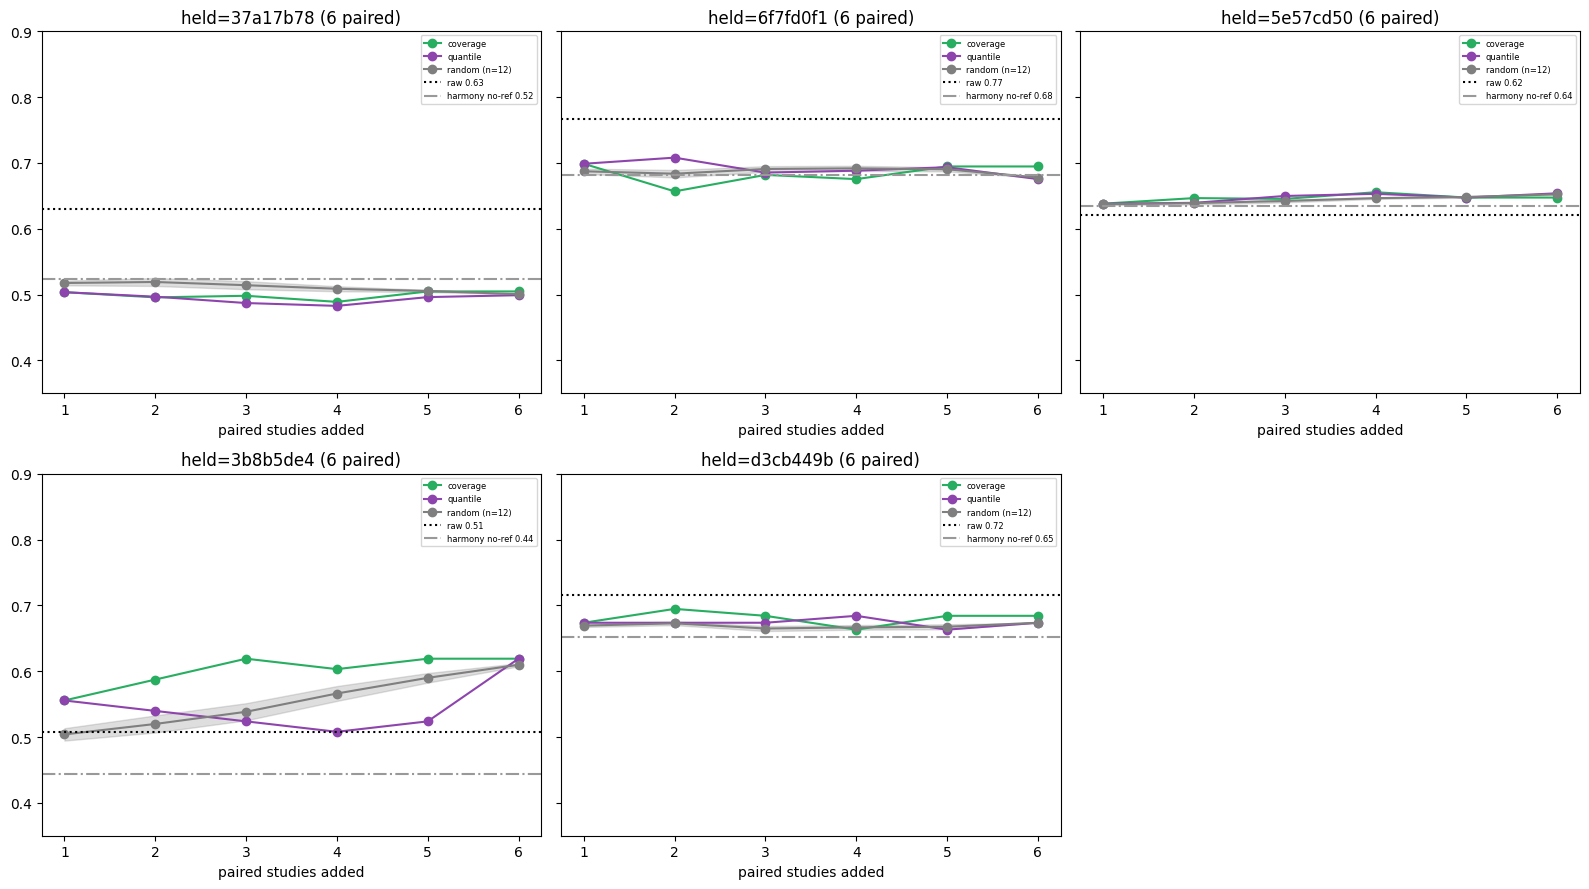

In [3]:
HELD_ALL = ["37a17b78", "6f7fd0f1", "5e57cd50", "3b8b5de4", "d3cb449b"]
KS = [1, 2, 3, 4, 5, 6]
NSEED = {"coverage": 1, "quantile": 1, "random": 12}
COLS = {"coverage": "#27ae60", "quantile": "#8e44ad", "random": "#7f7f7f"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.ravel()
for ax, H in zip(axes, HELD_ALL):
    core, held_pid, DEM_SRC, NORMAL_SRC = setup_held(H)
    pstud = paired_studies(H, DEM_SRC, NORMAL_SRC)
    kmax = min(max(KS), len(pstud))
    ks = [k for k in KS if k <= kmax]
    res = {h: {k: [] for k in ks} for h in NSEED}
    for how in NSEED:
        for seed in range(NSEED[how]):
            ordered = order_studies(pstud, how, seed)
            for k in ks:
                res[how][k].append(evaluate(core, build_refs(pstud, ordered, k), held_pid))
    raw = evaluate(core, [], held_pid, do_harmony=False)
    harm0 = evaluate(core, [], held_pid, do_harmony=True)
    for how in NSEED:
        m = np.array([np.mean(res[how][k]) for k in ks])
        if how == "random":
            se = np.array([np.std(res[how][k], ddof=1) / np.sqrt(NSEED["random"]) for k in ks])
            ax.plot(ks, m, "-o", color=COLS[how], label=f"random (n={NSEED['random']})")
            ax.fill_between(ks, m - se, m + se, color=COLS[how], alpha=0.25)
        else:
            ax.plot(ks, m, "-o", color=COLS[how], label=how)
    ax.axhline(raw, ls=":", color="black", label=f"raw {raw:.2f}")
    ax.axhline(harm0, ls="-.", color="0.6", label=f"harmony no-ref {harm0:.2f}")
    ax.set_title(f"held={H} ({len(pstud)} paired)")
    ax.set_xlabel("paired studies added")
    ax.set_ylim(0.35, 0.90)
    ax.legend(fontsize=6)
    print(f"{H}: paired={len(pstud)} | " + " ".join(f"{how}@max={np.mean(res[how][ks[-1]]):.3f}" for how in NSEED), flush=True)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()